# 7. Canopy structure

Vertical profiles and plant area from a point cloud, and gap fraction from
pulse data. For the rigorous ray-traced version see notebook 9.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import canopy, filters, ground

cloud = filters.voxel_downsample(sylva.read(DATA / "litch_tile.laz"), 0.05)
dtm = ground.make_dtm(ground.classify_ground_pmf(cloud), 0.5, bounds=(0, 0, 20, 20))
cloud = ground.normalize_height(cloud, dtm)

The data: a 20 x 20 m tile of the TERN [Litchfield Savanna
SuperSite](https://www.tern.org.au) plot in the Northern Territory, scanned in
2021 with a RIEGL VZ-2000i from many positions and registered into one cloud.
`litch_tile.laz` holds the echoes inside the tile thinned to 5 cm, with
`classification` (2 ground, 4 vegetation) and `intensity`;
`litch_tile_shots.parquet` holds every 40th pulse, clipped to the tile, misses
included. The plot data are TERN's; `make_litch_subset.py` cuts the tile.

## Occupancy and the contact-frequency profile

`voxelize` counts points per voxel. `pad_profile_voxel` turns the fraction of
occupied voxels per layer into plant area density (a simplified Hosoi & Omasa
2006, assuming vertical beams and G = 0.5). Both ignore occlusion and both
depend on the point density, so they describe the cloud as much as the canopy
-- pulse data (notebook 9) is what measures the canopy.

voxel grid (nx, ny, nz): (81, 81, 80)
PAI from voxel occupancy: 4.47   (the ray-traced plot value for Litchfield is 1.4, see the canopy benchmark)


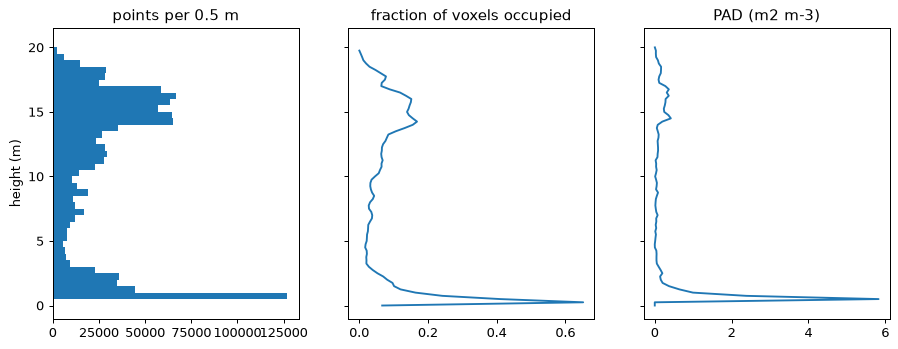

In [2]:
veg = cloud[cloud.attrs["height"] > 0.5]
grid = canopy.voxelize(veg, 0.25)
z, pad = canopy.pad_profile_voxel(veg, voxel_size=0.25)
print("voxel grid (nx, ny, nz):", grid.shape)
print("PAI from voxel occupancy:", round(float(np.nansum(pad) * 0.25), 2),
      "  (the ray-traced plot value for Litchfield is 1.4, see the canopy benchmark)")

hb, counts = canopy.vertical_profile(veg, bin_size=0.5)
fig, ax = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)
ax[0].barh(hb, counts, height=0.5, align="edge"); ax[0].set(title="points per 0.5 m", ylabel="height (m)")
ax[1].plot(grid.vertical_profile(), grid.z_levels() - grid.origin[2]); ax[1].set(title="fraction of voxels occupied")
ax[2].plot(pad, z); ax[2].set(title="PAD (m2 m-3)");

The savanna's structure shows in all three: a dense grass and shrub
layer below 2 m, a sparse middle, and a canopy from 8 m to 20 m. The point
profile exaggerates the lower layers, which are metres from the scanners; the
occupancy profile is flatter because a voxel counts once however many points
it holds.

## Canopy cover and the CHM

In [3]:
chm = ground.make_chm(cloud, resolution=0.5)
for h in (0.5, 2.0, 5.0, 10.0):
    print(f"cover above {h:4.1f} m: {canopy.canopy_cover(chm.data, h):.2f}")

cover above  0.5 m: 0.96
cover above  2.0 m: 0.68
cover above  5.0 m: 0.62
cover above 10.0 m: 0.57


## Gap fraction from pulses

Gap fraction inverts the fraction of pulses that got through at each zenith
angle, so it needs pulses with their scanner origins. The tile's pulse file
cannot serve here: its rays were clipped at the tile boundary, so their origins
sit on the tile edge rather than at a scanner (notebook 8). This part uses a
synthetic scene instead, where the leaf area is known -- see
[Pulse data](../guide/pulses.md) and the [canopy
benchmark](../benchmarks/canopy.md) for whole plots read from RIEGL `.rxp`,
where Sylva's profiles match pylidar-tls-canopy to within 4 %.

Shots(n_shots=748,800, n_echoes=78,034) - 91% of pulses returned nothing
true leaf area index of the scene: 0.30 (plus bark)
effective PAI (hinge): 0.12
effective PAI (miller): 0.13


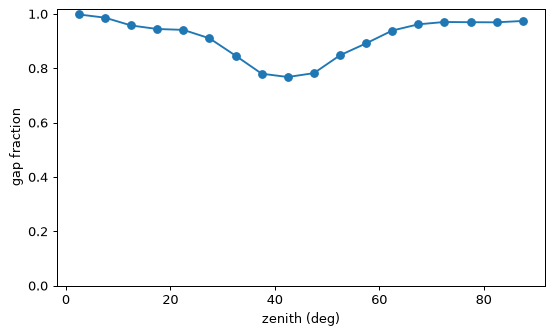

In [4]:
scene = synthetic.forest()
shots = synthetic.scan(scene, origin=(10.0, 10.0, 1.5), resolution_deg=0.25)
print(shots, f"- {np.mean(shots.echo_count == 0):.0%} of pulses returned nothing")
print(f"true leaf area index of the scene: {synthetic.leaf_area(scene) / 20**2:.2f} (plus bark)")
echo_height = shots.echo_xyz()[:, 2] - synthetic.terrain_height(*shots.echo_xyz()[:, :2].T)
zen, gap = canopy.gap_fraction_zenith(shots, echo_height, min_height=1.0, zenith_edges=np.arange(0, 95, 5.0))
for method in ("hinge", "miller"):
    print(f"effective PAI ({method}): {canopy.lai_from_gap_fraction(zen, gap, method):.2f}")
plt.plot(zen, gap, "o-"); plt.gca().set(xlabel="zenith (deg)", ylabel="gap fraction", ylim=(0, 1.02));

Both estimators land well below the scene's 0.30, and that is the
point of the exercise: one scan from inside a scene of discrete leaf discs
misses most of the leaf area, and an *effective* PAI is a lower bound on the
real one. Several positions, or the ray-traced voxels of notebook 9, recover
more of it.